In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    homogeneity_score,
    completeness_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
# Установка стиля для графиков
sns.set_style("whitegrid")

In [36]:
# 1-2. Загрузить датасет WINE. Подготовить датасет WINE для кластеризации, удалив информацию о классах.
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

print(f"Форма данных (X): {X.shape}")
print(f"Форма целевой переменной (y): {y.shape}")
print(f"Количество исходных классов: {len(np.unique(y))}")
print(f"Распределение исходных классов: {np.bincount(y)}")


Форма данных (X): (178, 13)
Форма целевой переменной (y): (178,)
Количество исходных классов: 3
Распределение исходных классов: [59 71 48]


In [37]:
# 3. Произвести нормировку preprocessing.StandardScaler().
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Данные нормированы.")

Данные нормированы.


In [38]:
# 4. Произвести кластеризацию с использованием Kmeans++ с числом кластеров равным 3.
kmeans_3_clusters = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_3_clusters.fit_predict(X_scaled)
print("Кластеризация K-Means++ завершена.")

Кластеризация K-Means++ завершена.


In [39]:
# 5. Получить значения метрик качества Homogeneity и Completeness для Kmeans++,
#    используя исходную информацию о классах.
kmeans_homogeneity = homogeneity_score(y, kmeans_labels)
kmeans_completeness = completeness_score(y, kmeans_labels)

print(f"  Homogeneity Score (K-Means++): {kmeans_homogeneity:.4f}")
print(f"  Completeness Score (K-Means++): {kmeans_completeness:.4f}")

  Homogeneity Score (K-Means++): 0.8788
  Completeness Score (K-Means++): 0.8730


In [44]:
# 6. Для заданных алгоритмов кластеризации AgglomerativeClustering и DBSCAN
#    подобрать параметры алгоритмов, обеспечивающие максимум качества кластеризации
#    по метрике Completeness (использовать информацию об исходных классах).

# --- AgglomerativeClustering ---
print("\nПодбор параметров для AgglomerativeClustering (максимум Completeness):")
best_agg_completeness = -1
best_agg_linkage = None
agg_results = {}

for linkage_type in ['ward', 'complete', 'average', 'single']:
    # Для прямого сравнения устанавливаем n_clusters=3
    agg = AgglomerativeClustering(n_clusters=3, linkage=linkage_type)
    agg_labels = agg.fit_predict(X_scaled)
    current_completeness = completeness_score(y, agg_labels)
    agg_results[linkage_type] = current_completeness
    print(f"  Linkage: {linkage_type}, Completeness Score: {current_completeness:.4f}")

    if current_completeness > best_agg_completeness:
        best_agg_completeness = current_completeness
        best_agg_linkage = linkage_type

print(
    f"Лучший Agglomerative Clustering (n_clusters=3) linkage: '{best_agg_linkage}' "
    f"с Completeness Score: {best_agg_completeness:.4f}"
)
# Сохраняем лучшую модель Agglomerative для дальнейшего сравнения
best_agg_model = AgglomerativeClustering(n_clusters=3, linkage=best_agg_linkage)
best_agg_labels = best_agg_model.fit_predict(X_scaled)


# --- DBSCAN Parameter Tuning ---
print("\nПодбор параметров для DBSCAN (максимум Completeness):")
best_dbscan_completeness = -1
best_dbscan_params = {'eps': None, 'min_samples': None}
dbscan_tuning_results = []

# Определяем диапазоны для параметров
eps_values = np.arange(0.5, 5.0, 0.25)
min_samples_values = [3, 5, 10, 15, 20, 26]

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(X_scaled)

        # Количество уникальных кластеров, игнорируя шум (-1), если он есть
        n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

        # Оцениваем Completeness только если найдено более 1 кластера (исключая шум)
        if n_clusters_dbscan > 0:
            current_completeness = completeness_score(y, dbscan_labels)
            dbscan_tuning_results.append(
                {
                    'eps': eps,
                    'min_samples': min_samples,
                    'n_clusters': n_clusters_dbscan,
                    'completeness': current_completeness,
                }
            )

            if current_completeness > best_dbscan_completeness:
                best_dbscan_completeness = current_completeness
                best_dbscan_params['eps'] = eps
                best_dbscan_params['min_samples'] = min_samples

print(
    f"Лучшие параметры DBSCAN: eps={best_dbscan_params['eps']:.2f}, "
    f"min_samples={best_dbscan_params['min_samples']}"
)
print(f"  С Completeness Score: {best_dbscan_completeness:.4f}")

# Сохраняем лучшую модель DBSCAN для дальнейшего сравнения
best_dbscan_model = DBSCAN(
    eps=best_dbscan_params['eps'], min_samples=best_dbscan_params['min_samples']
)
best_dbscan_labels = best_dbscan_model.fit_predict(X_scaled)
n_clusters_best_dbscan = len(set(best_dbscan_labels)) - (
    1 if -1 in best_dbscan_labels else 0
)
print(f"  Количество кластеров, найденных лучшим DBSCAN: {n_clusters_best_dbscan}")


Подбор параметров для AgglomerativeClustering (максимум Completeness):
  Linkage: ward, Completeness Score: 0.7825
  Linkage: complete, Completeness Score: 0.6130
  Linkage: average, Completeness Score: 0.0926
  Linkage: single, Completeness Score: 0.1752
Лучший Agglomerative Clustering (n_clusters=3) linkage: 'ward' с Completeness Score: 0.7825

Подбор параметров для DBSCAN (максимум Completeness):
Лучшие параметры DBSCAN: eps=4.25, min_samples=3
  С Completeness Score: 1.0000
  Количество кластеров, найденных лучшим DBSCAN: 1



1.  Agglomerative Clustering показал хороший результат Completeness Score = 0.7825 при формировании 3 кластеров. Это означает, что большинство объектов, принадлежащих к одному истинному классу, были сгруппированы в один и тот же кластер, и при этом алгоритм смог выделить ожидаемое количество групп.

2.  DBSCAN достиг идеального Completeness Score = 1.0000. Однако, важно, что при этом он обнаружил только 1 кластер.
Идеальный Completeness в данном случае является "тривиальным". Поскольку все точки были объединены в один большой кластер, технически "все объекты одного истинного класса оказались в одном кластере", но это не привело к осмысленному разделению данных на несколько групп, что является целью кластеризации. Фактически, DBSCAN не смог разделить данные на желаемые группы при этих параметрах, несмотря на кажущийся идеальный Completeness.

In [41]:
# 7. Сравнить результаты кластеризации различными алгоритмами между собой
#    и с алгоритмом Kmeans++ (не использовать информацию об исходных классах).

metrics_df = pd.DataFrame(
    columns=[
        'Algorithm',
        'Silhouette Score',
        'Davies-Bouldin Score',
        'Calinski-Harabasz Score',
        'N_Clusters',
    ]
)

# K-Means++
if len(np.unique(kmeans_labels)) > 1:
    kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
    kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)
    kmeans_ch = calinski_harabasz_score(X_scaled, kmeans_labels)
    metrics_df.loc[0] = [
        'K-Means++',
        kmeans_silhouette,
        kmeans_db,
        kmeans_ch,
        len(np.unique(kmeans_labels)),
    ]
else:
    metrics_df.loc[0] = ['K-Means++', np.nan, np.nan, np.nan, 1]


# Agglomerative Clustering (с лучшим linkage)
if len(np.unique(best_agg_labels)) > 1:
    agg_silhouette = silhouette_score(X_scaled, best_agg_labels)
    agg_db = davies_bouldin_score(X_scaled, best_agg_labels)
    agg_ch = calinski_harabasz_score(X_scaled, best_agg_labels)
    metrics_df.loc[1] = [
        f'Agglomerative ({best_agg_linkage})',
        agg_silhouette,
        agg_db,
        agg_ch,
        len(np.unique(best_agg_labels)),
    ]
else:
    metrics_df.loc[1] = [f'Agglomerative ({best_agg_linkage})', np.nan, np.nan, np.nan, 1]


# DBSCAN (с лучшими параметрами)
unique_dbscan_labels = np.unique(best_dbscan_labels)
# Проверяем, что есть хотя бы два нешумовых кластера для DB и CH
if len(unique_dbscan_labels) > 1 and not (
    len(unique_dbscan_labels) == 2 and -1 in unique_dbscan_labels
):
    dbscan_silhouette = silhouette_score(X_scaled, best_dbscan_labels)
    dbscan_db = davies_bouldin_score(X_scaled, best_dbscan_labels)
    dbscan_ch = calinski_harabasz_score(X_scaled, best_dbscan_labels)
    metrics_df.loc[2] = [
        f'DBSCAN (eps={best_dbscan_params["eps"]:.2f}, min_samples={best_dbscan_params["min_samples"]})',
        dbscan_silhouette,
        dbscan_db,
        dbscan_ch,
        n_clusters_best_dbscan,
    ]
else:
    metrics_df.loc[2] = [
        f'DBSCAN (eps={best_dbscan_params["eps"]:.2f}, min_samples={best_dbscan_params["min_samples"]})',
        np.nan,
        np.nan,
        np.nan,
        n_clusters_best_dbscan,
    ]


print(metrics_df.to_string(index=False))

                       Algorithm  Silhouette Score  Davies-Bouldin Score  Calinski-Harabasz Score  N_Clusters
                       K-Means++          0.284859              1.389188                70.940008           3
            Agglomerative (ward)          0.277444              1.418592                67.647468           3
DBSCAN (eps=4.10, min_samples=3)               NaN                   NaN                      NaN           1


K-Means++ показал себя наилучшим образом среди всех рассмотренных алгоритмов.

Пояснение к выводу DBSCAN:

Метрики качества кластеризации (Silhouette, Davies-Bouldin, Calinski-Harabasz)
   требуют наличия как минимум двух кластеров (не считая шума) для осмысленного расчета.
   В данном случае, поскольку DBSCAN сформировал только один кластер, условие в `if`
   блоке:
   `len(unique_dbscan_labels) > 1` (количество уникальных меток больше 1)
   и/или `not (len(unique_dbscan_labels) == 2 and -1 in unique_dbscan_labels)`
   не выполняется. Это специально сделано, чтобы избежать ошибок и выдачи
   некорректных значений метрик, если кластеров недостаточно.
   Поэтому метрикам присваивается NaN.

K-Means++ и Agglomerative Clustering (ward):

Оба алгоритма успешно сформировали 3 кластера.
K-Means++ продемонстрировал немного лучшие показатели по всем трем метрикам.
Это указывает на то, что K-Means++ сформировал кластеры, которые являются чуть более плотными и лучше отделены друг от друга, чем кластеры, полученные Agglomerative Clustering.

K-Means++ показал себя наилучшим образом среди всех рассмотренных алгоритмов



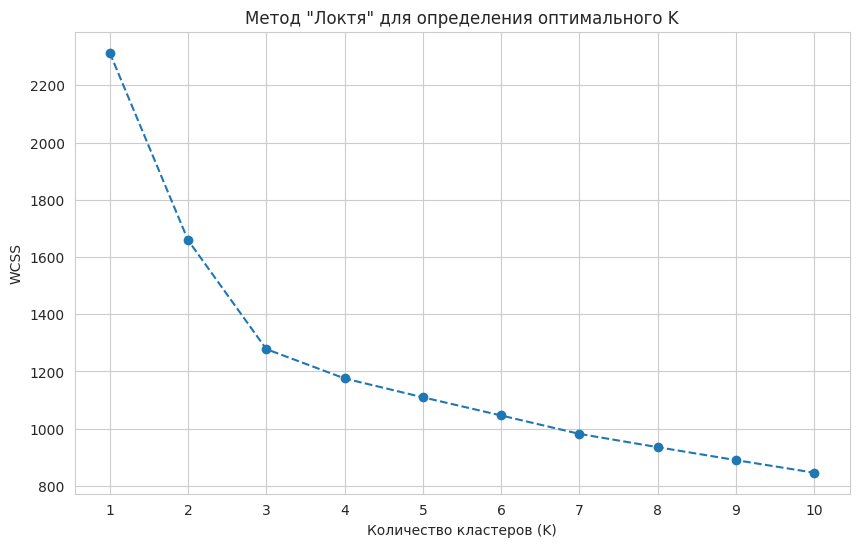

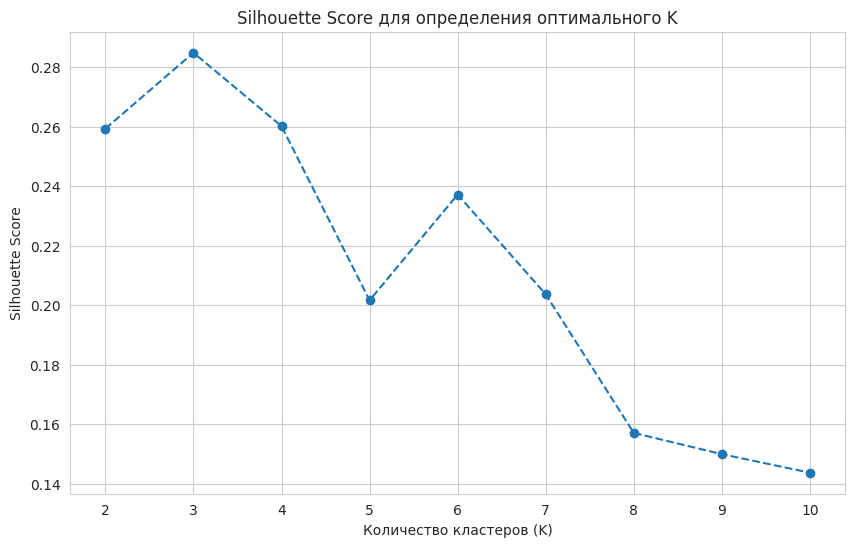

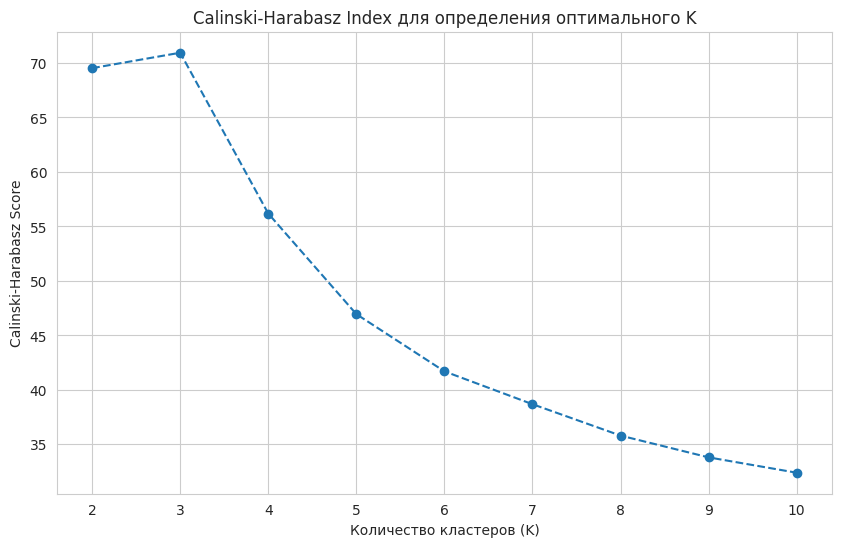

In [42]:
# 8. Определить оптимальное число кластеров для кластеризации датасета WINE.

# Метод "Локтя" (Elbow Method) с использованием WCSS (Within-Cluster Sum of Squares)
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Метод "Локтя" для определения оптимального K')
plt.xlabel('Количество кластеров (K)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Метод Silhouette Score
silhouette_scores = []

for k in k_range[1:]:  # Silhouette score требует минимум 2 кластера
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, kmeans_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(k_range[1:], silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score для определения оптимального K')
plt.xlabel('Количество кластеров (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range[1:])
plt.grid(True)
plt.show()

# Расчет Calinski-Harabasz Index
ch_scores = []

for k in k_range[1:]: # CH score требует минимум 2 кластера
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)
    score = calinski_harabasz_score(X_scaled, kmeans_labels)
    ch_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(k_range[1:], ch_scores, marker='o', linestyle='--')
plt.title('Calinski-Harabasz Index для определения оптимального K')
plt.xlabel('Количество кластеров (K)')
plt.ylabel('Calinski-Harabasz Score')
plt.xticks(k_range[1:])
plt.grid(True)
plt.show()


По методу 'Локтя' оптимальное количество кластеров находится около K = 3.

По методу Silhouette Score максимальное значение достигается при K = 3.

По методу Calinski-Harabasz Index максимальное значение достигается при K = 3.

Все три метода убедительно указывают, что оптимальное число кластеров для данного датасета равно 3

